# Numerical Simulation Laboratory - Exercise 2

## INTRODUCTION

In this second exercise two standard applications of Monte Carlo methods are studied: Monte Carlo integration with importance sampling and three-dimensional random walks.

### Importance sampling

Monte Carlo integration allows an integral to be estimated as an average over random samples. In this exercise the integration interval is $[0,1]$, so an integral of the form

$$
I=\int_0^1 f(x)\,dx
$$

can be estimated by sampling points uniformly in the interval and averaging the values of the integrand, since the length of the interval is one.

A more general formulation is obtained by introducing a normalized probability density $p(x)$ in the integration interval:

$$
I=\int_0^1 \frac{f(x)}{p(x)}p(x)\,dx.
$$

In this form, the points are sampled according to $p(x)$ and the averaged quantity is $f(x)/p(x)$. This method is called importance sampling. The value of the integral is not changed, but the sampling strategy is modified.

The aim of importance sampling is to reduce the variance of the estimator. A good probability density $p(x)$ should be positive, normalized, and similar to the shape of the integrand, so that the regions giving the largest contribution to the integral are sampled more frequently. With a suitable choice of $p(x)$, the same number of Monte Carlo throws can lead to a smaller statistical uncertainty.

### Random walks and diffusion

A random walk is a stochastic process in which a particle performs a sequence of random steps. In this exercise, the walk starts from the origin and each step has fixed length $a=1$.

For an ordinary diffusive random walk, the average displacement is zero, but the mean square displacement grows linearly with the number of steps:

$$
\langle |\vec r_N|^2 \rangle_{RW} \propto N.
$$

Therefore, the root mean square distance from the origin behaves as

$$
\sqrt{\langle |\vec r_N|^2 \rangle_{RW}} \propto \sqrt{N}.
$$

This square-root behaviour is the typical signature of diffusion. In the exercise, it is tested both for a random walk on a cubic lattice and for a random walk in continuous three-dimensional space.

In both parts of the exercise, statistical uncertainties are estimated with the blocking method.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Files produced by the C++ codes
data_1 = pd.read_csv("Results/Esercizio_02.1_results.txt", sep=";")
data_2 = pd.read_csv("Results/Esercizio_02.2_results.txt", sep=";")

## EXERCISE 2.1

### Assignment prompt

**Exercise 02.1** - Compute the following one-dimensional integral via Monte Carlo:

$$
I = \int_0^1 \frac{\pi}{2}\cos\left(\frac{\pi x}{2}\right)\,dx = 1.
$$

Use:

1. sampling from a uniform distribution in $[0,1]$;
2. importance sampling, i.e. sampling from a non-uniform probability distribution in $[0,1]$.

Show a picture of both estimations of $I$ and their uncertainties with a large number of throws $M$, for instance $M \ge 10^4$, as a function of the number of blocks $N$.

### Method

In this exercise the integrand is

$$
f(x)=\frac{\pi}{2}\cos\left(\frac{\pi x}{2}\right),
$$

and the integral is evaluated on the interval $[0,1]$.

With uniform sampling, the random variable $x$ is sampled uniformly in $[0,1]$ and the estimator used in the simulation is

$$
I \simeq \frac{1}{M}\sum_{i=1}^{M} f(x_i).
$$

For importance sampling, the probability density used in the code is

$$
p(x)=2(1-x),
\qquad \int_0^1 p(x)\,dx=1.
$$



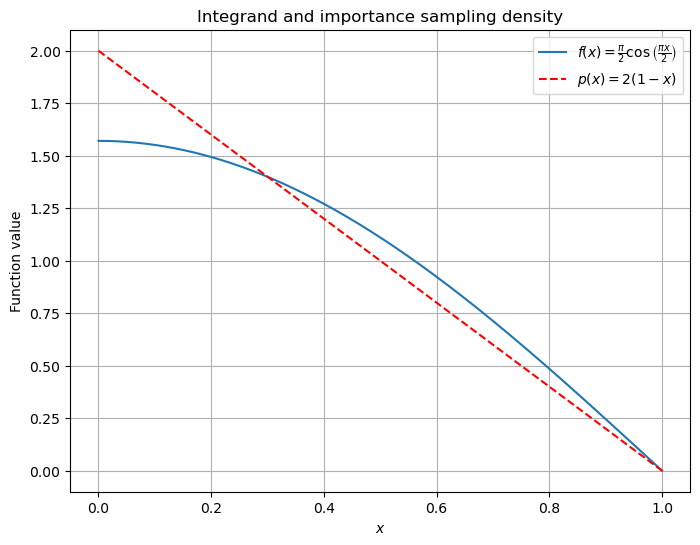

In [3]:
x = np.linspace(0, 1, 1000)

f_x = np.pi/2 * np.cos(np.pi*x/2)
p_x = 2*(1-x)

plt.figure(figsize=(8, 6))
plt.plot(x, f_x, label=r"$f(x)=\frac{\pi}{2}\cos\left(\frac{\pi x}{2}\right)$")
plt.plot(x, p_x, 'r--', label=r"$p(x)=2(1-x)$")
plt.xlabel(r"$x$")
plt.ylabel("Function value")
plt.title("Integrand and importance sampling density")
plt.grid(True)
plt.legend()
plt.show()

The plot shows why this is a reasonable choice. The probability density $p(x)=2(1-x)$ is not identical to the integrand, but it has a similar behaviour: both functions are positive and decreasing in the interval $[0,1]$. Therefore, the sampling gives more weight to the region near $x=0$, where the integrand is larger and contributes more to the value of the integral.

The cumulative distribution associated with $p(x)$ is

$$
F(x)=\int_0^x 2(1-t)\,dt = 2x-x^2.
$$

If $y$ is uniformly distributed in $[0,1]$, the inverse cumulative method gives

$$
y=2x-x^2
\quad \Rightarrow \quad
x=1-\sqrt{1-y}.
$$

Therefore, the importance sampling estimator used in the simulation is

$$
I \simeq \frac{1}{M}\sum_{i=1}^{M}\frac{f(x_i)}{2(1-x_i)},
\qquad x_i \sim p(x).
$$

Both the integrand and $p(x)$ vanish at $x=1$, but they vanish with the same order. Therefore, the ratio $f(x)/p(x)$ has a finite limit and the estimator is well behaved. In practice, the random generator does not sample exactly $x=1$.

The simulation uses $M=10^4$ throws divided into $N=100$ blocks. The final estimate and its uncertainty are obtained from the progressive average of the block averages.

### C++ implementation

The integrand is implemented as:

```cpp
double integranda(double x){
   return (M_PI/2)*cos((M_PI/2)*x);
}
```

Uniform sampling uses direct calls to the uniform random generator:

```cpp
for(int j=0; j<throws_per_block; j++){
   sum += integranda(rnd.Rannyu());
}
```

The importance sampling variable is generated by inverse transform sampling:

```cpp
double Random :: cos_importance_sampling(){
   double y = Rannyu();
   return 1 - sqrt(1-y);
}
```

and the sampled quantity is weighted by $1/p(x)$:

```cpp
double x = rnd.cos_importance_sampling();
sum += integranda(x)/(2.0*(1.0-x));
```

### Results

The statistical uncertainties are estimated with the blocking method and are shown as error bars in the plots. Each point represents the progressive estimate of the integral after a given number of blocks.

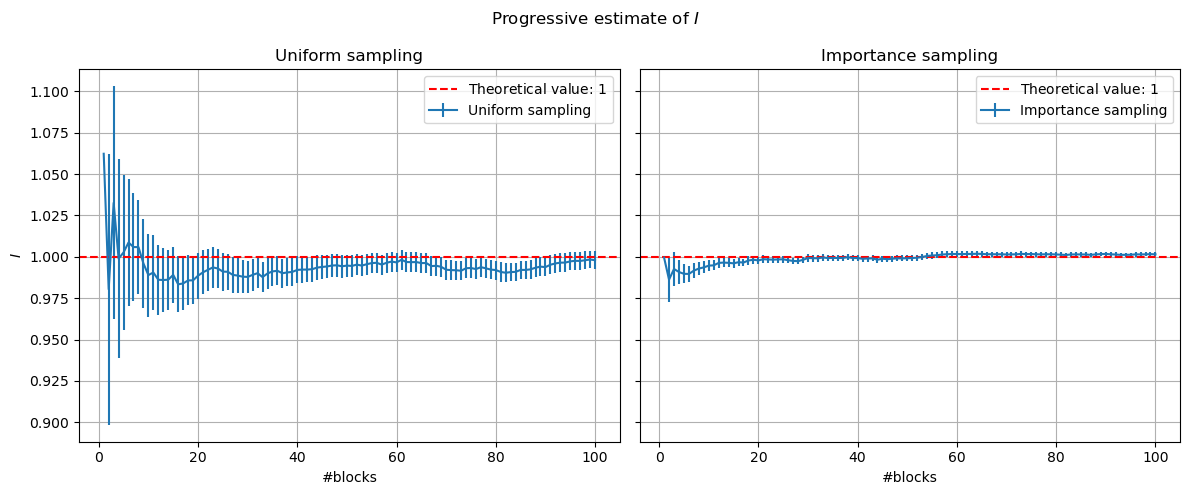

Final estimate with uniform sampling: I = 0.997939 ± 0.005284
Final estimate with importance sampling: I = 1.001520 ± 0.001270
Theoretical value: I = 1.000000


In [4]:
N_blocks = len(data_1)
blocks = np.arange(1, N_blocks + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].errorbar(blocks, data_1["Progressive_integral_uniform_sampling"],
                 yerr=data_1["Progressive_integral_uniform_sampling_error"],
                 label="Uniform sampling")
axes[0].axhline(y=1, color='r', linestyle='--', label=r'Theoretical value: $1$')
axes[0].set_title("Uniform sampling")
axes[0].set_xlabel("#blocks")
axes[0].set_ylabel(r"$I$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(blocks, data_1["Progressive_integral_importance_sampling"],
                 yerr=data_1["Progressive_integral_importance_sampling_error"],
                 label="Importance sampling")
axes[1].axhline(y=1, color='r', linestyle='--', label=r'Theoretical value: $1$')
axes[1].set_title("Importance sampling")
axes[1].set_xlabel("#blocks")
axes[1].grid(True)
axes[1].legend()

fig.suptitle(r"Progressive estimate of $I$")
plt.tight_layout()
plt.show()

print(f"Final estimate with uniform sampling: I = {data_1['Progressive_integral_uniform_sampling'].iloc[-1]:.6f} ± {data_1['Progressive_integral_uniform_sampling_error'].iloc[-1]:.6f}")
print(f"Final estimate with importance sampling: I = {data_1['Progressive_integral_importance_sampling'].iloc[-1]:.6f} ± {data_1['Progressive_integral_importance_sampling_error'].iloc[-1]:.6f}")
print(f"Theoretical value: I = 1.000000")

### Comment

Both progressive estimates are compatible with the analytical result $I=1$ within the final statistical uncertainty.

The final values are

$$
I_{\mathrm{uniform}} = 0.997939 \pm 0.005284,
$$

and

$$
I_{\mathrm{importance}} = 1.00152 \pm 0.00127.
$$

The important difference is the size of the uncertainty. With the same total number of throws, the importance sampling estimate has a much smaller statistical error. This happens because the chosen probability density $p(x)=2(1-x)$ roughly follows the decreasing shape of the integrand, so the sampling is more concentrated in the region that contributes most to the integral.

This does not mean that importance sampling is always better automatically. The improvement depends on choosing a normalized probability density close enough to the relevant shape of the integrand.

## EXERCISE 2.2

### Assignment prompt

**Exercise 02.2** - Simulate many times, for instance $10^4$ times, a three-dimensional random walk always starting at the origin.

Consider:

1. a random walk on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length $a$ in one of the three principal directions $x$, $y$, or $z$
2. a random walk in the continuum; at each discrete time the walker makes a step of length $a=1$ along a random direction obtained by sampling uniformly the solid angle, with $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$.

Show a picture of

$$
\sqrt{\langle |\vec r_N|^2 \rangle_{RW}}
$$

for both random walks, with statistical uncertainties, as a function of the step $N \in [0,10^2]$.

Note that you could try to fit both results with a function like

$$
f(N)=k\sqrt{N}.
$$

Do your results indicate a diffusive behavior?

### Method

For each value of the number of steps $N$, the code generates many independent random walks starting from the origin. For each trajectory it computes

$$
|\vec r_N|^2 = x_N^2+y_N^2+z_N^2.
$$

The average over the random walks gives $\langle |\vec r_N|^2 \rangle_{RW}$, and the plotted quantity is its square root:

$$
\sqrt{\langle |\vec r_N|^2 \rangle_{RW}}.
$$

In the cubic lattice case, each step changes exactly one Cartesian coordinate by $+1$ or $-1$. The coordinate is selected randomly among $x$, $y$ and $z$, while the sign is selected with equal probability. Therefore, each step is one of the six possible moves

$$
(\pm 1,0,0), \qquad (0,\pm 1,0), \qquad (0,0,\pm 1).
$$

In the continuum case, each step still has fixed length $a=1$, but its direction is sampled uniformly on the sphere. To sample the solid angle uniformly, it is not correct to sample $\theta$ uniformly in $[0,\pi]$. The correct procedure is to sample

$$
\phi \sim U(0,2\pi),
\qquad
\cos\theta \sim U(-1,1),
$$

and then use

$$
\Delta x = \sin\theta\cos\phi,
\qquad
\Delta y = \sin\theta\sin\phi,
\qquad
\Delta z = \cos\theta.
$$

For both random walks, the numerical results are fitted with

$$
f(N)=k\sqrt{N},
$$

so that the fitted value of $k$ can be used to check the expected diffusive behaviour.

### C++ implementation

The **lattice step** is implemented by first choosing the axis and then the sign:

```cpp
void discrete_step(Random &rnd, double &x, double &y, double &z){
   double p = rnd.Rannyu();
   if(p < (1./3.)){
      double l = rnd.Rannyu();
      if(l < 1./2.) x += 1;
      else x -= 1;
   }
   else if(p < (2./3.)){
      double l = rnd.Rannyu();
      if(l < 1./2.) y += 1;
      else y -= 1;
   }
   else{
      double l = rnd.Rannyu();
      if(l < 1./2.) z += 1;
      else z -= 1;
   }
}
```

The **continuous step** samples $\phi$ uniformly and $\cos\theta$ uniformly:

```cpp
void continuous_step(Random &rnd, double &x, double &y, double &z){
   double phi = rnd.Rannyu(0, 2*M_PI);
   double costheta = rnd.Rannyu(-1, 1);
   double sintheta = sqrt(1 - costheta*costheta);

   x += sintheta*cos(phi);
   y += sintheta*sin(phi);
   z += costheta;
}
```

The simulation uses $M=10^4$ random walks divided into $100$ blocks and evaluates the distance from the origin up to $100$ steps.

### Results

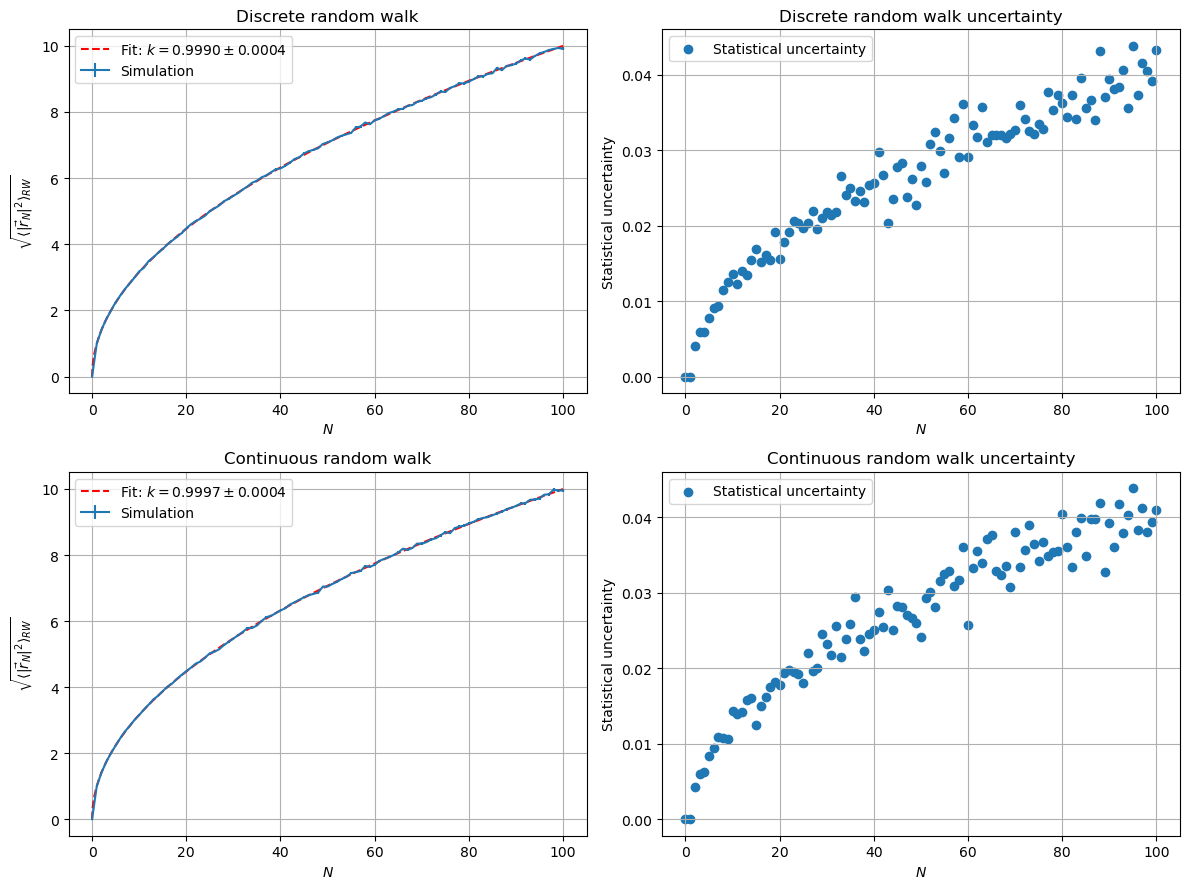

Fit parameter for the lattice random walk: k = 0.999046 ± 0.000394
Fit parameter for the continuous random walk: k = 0.999742 ± 0.000403


In [5]:
final_block = data_2["Block"].max()
final_data = data_2[data_2["Block"] == final_block].copy()

steps = final_data["Step"].values

def fit_sqrt_law(x, y, sigma):
    mask = (x > 0) & (sigma > 0)
    X = np.sqrt(x[mask])
    Y = y[mask]
    S = sigma[mask]
    weights = 1.0 / S**2
    k = np.sum(weights * X * Y) / np.sum(weights * X**2)
    k_err = np.sqrt(1.0 / np.sum(weights * X**2))
    residuals = (Y - k * X) / S
    chi2 = np.sum(residuals**2)
    ndof = len(Y) - 1
    return k, k_err, chi2 / ndof

discrete_rw = final_data["Progressive_discrete_rw"].values
discrete_rw_error = final_data["Progressive_discrete_rw_error"].values

continuous_rw = final_data["Progressive_continuous_rw"].values
continuous_rw_error = final_data["Progressive_continuous_rw_error"].values

k_discrete, k_discrete_error, chi2_discrete = fit_sqrt_law(
    steps, discrete_rw, discrete_rw_error
)

k_continuous, k_continuous_error, chi2_continuous = fit_sqrt_law(
    steps, continuous_rw, continuous_rw_error
)

x_fit = np.linspace(0, steps.max(), 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].errorbar(steps, discrete_rw, yerr=discrete_rw_error, label="Simulation")
axes[0, 0].plot(
    x_fit,
    k_discrete * np.sqrt(x_fit),
    'r--',
    label=rf"Fit: $k={k_discrete:.4f}\pm{k_discrete_error:.4f}$"
)
axes[0, 0].set_title(r"Discrete random walk")
axes[0, 0].set_xlabel(r"$N$")
axes[0, 0].set_ylabel(r"$\sqrt{\langle |\vec r_N|^2 \rangle_{RW}}$")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].scatter(steps, discrete_rw_error, label="Statistical uncertainty")
axes[0, 1].set_title(r"Discrete random walk uncertainty")
axes[0, 1].set_xlabel(r"$N$")
axes[0, 1].set_ylabel("Statistical uncertainty")
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].errorbar(steps, continuous_rw, yerr=continuous_rw_error, label="Simulation")
axes[1, 0].plot(
    x_fit,
    k_continuous * np.sqrt(x_fit),
    'r--',
    label=rf"Fit: $k={k_continuous:.4f}\pm{k_continuous_error:.4f}$"
)
axes[1, 0].set_title(r"Continuous random walk")
axes[1, 0].set_xlabel(r"$N$")
axes[1, 0].set_ylabel(r"$\sqrt{\langle |\vec r_N|^2 \rangle_{RW}}$")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].scatter(steps, continuous_rw_error, label="Statistical uncertainty")
axes[1, 1].set_title(r"Continuous random walk uncertainty")
axes[1, 1].set_xlabel(r"$N$")
axes[1, 1].set_ylabel("Statistical uncertainty")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Fit parameter for the lattice random walk: k = {k_discrete:.6f} ± {k_discrete_error:.6f}")
print(f"Fit parameter for the continuous random walk: k = {k_continuous:.6f} ± {k_continuous_error:.6f}")

For each value of the number of steps $N$, the statistical uncertainty on $\sqrt{\langle |\vec r_N|^2\rangle_{RW}}$ is estimated with the blocking method. The error bars are included in the random walk plots, but they are very small compared with the scale of the root mean square distance. For this reason, the uncertainties are also shown separately in the right panels.

The plotted uncertainties are absolute uncertainties. Their slow increase with $N$ is therefore not unexpected, since the quantity $\sqrt{\langle |\vec r_N|^2\rangle_{RW}}$ itself grows approximately as $\sqrt{N}$.

### Do your results indicate a diffusive behavior?

The results are compatible with a diffusive behavior for both random walks.

For the lattice random walk, the fit gives

$$
k_{\mathrm{discrete}} = 0.9990 \pm 0.0004,
$$

while for the continuous random walk the result is

$$
k_{\mathrm{continuous}} = 0.9997 \pm 0.0004.
$$

Both values are compatible with the theoretical expectation $k=1$. This confirms that

$$
\sqrt{\langle |\vec r_N|^2 \rangle_{RW}} \sim \sqrt{N},
$$

or, equivalently,

$$
\langle |\vec r_N|^2 \rangle_{RW} \sim N.
$$

The linear growth of the mean square displacement with the number of steps is the typical signature of diffusion. The conclusion is the same for the discrete lattice walk and for the continuous-space walk because in both cases the steps are independent and have the same fixed length.